In [46]:
import pandas as pd
import matplotlib.pyplot as plt


In [47]:
df = pd.read_csv("train.csv")

our_df = df[["SalePrice","GrLivArea","OverallQual","YearBuilt","MoSold","YrSold","Neighborhood"]]
our_df['Sold_Date'] = our_df['MoSold'].astype(str) + '.' + our_df['YrSold'].astype(str)
our_df

,SalePrice,GrLivArea,OverallQual,YearBuilt,MoSold,YrSold,Neighborhood,Sold_Date
0,208500,1710,7,2003,2,2008,CollgCr,2.2008
1,181500,1262,6,1976,5,2007,Veenker,5.2007
2,223500,1786,7,2001,9,2008,CollgCr,9.2008
3,140000,1717,7,1915,2,2006,Crawfor,2.2006
4,250000,2198,8,2000,12,2008,NoRidge,12.2008
...,...,...,...,...,...,...,...,...
1455,175000,1647,6,1999,8,2007,Gilbert,8.2007
1456,210000,2073,6,1978,2,2010,NWAmes,2.2010
1457,266500,2340,7,1941,5,2010,Crawfor,5.2010
1458,142125,1078,5,1950,4,2010,NAmes,4.2010


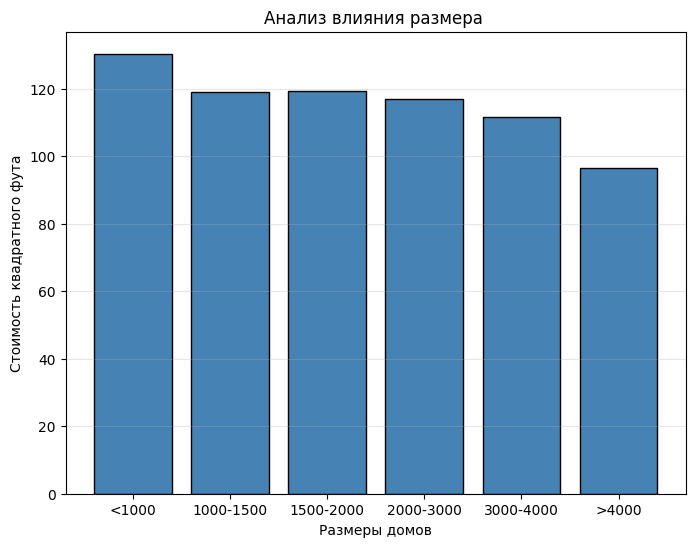

In [48]:
small_houses = our_df[our_df["GrLivArea"] < 1000]
medium1_houses = our_df[(our_df["GrLivArea"] < 1500) & (our_df["GrLivArea"] >= 1000)]
medium2_houses = our_df[(our_df["GrLivArea"] < 2000) & (our_df["GrLivArea"] >= 1500)]
medium3_houses = our_df[(our_df["GrLivArea"] < 3000) & (our_df["GrLivArea"] >= 2000)]
medium4_houses = our_df[(our_df["GrLivArea"] < 4000) & (our_df["GrLivArea"] >= 3000)]
large_houses = our_df[our_df["GrLivArea"] >= 4000]
agv_price_small = round(
    float(small_houses["SalePrice"].mean() / small_houses["GrLivArea"].mean()), 4
)
agv_price_medium1 = round(
    float(medium1_houses["SalePrice"].mean() / medium1_houses["GrLivArea"].mean()), 4
)
agv_price_medium2 = round(
    float(medium2_houses["SalePrice"].mean() / medium2_houses["GrLivArea"].mean()), 4
)
agv_price_medium3 = round(
    float(medium3_houses["SalePrice"].mean() / medium3_houses["GrLivArea"].mean()), 4
)
agv_price_medium4 = round(
    float(medium4_houses["SalePrice"].mean() / medium4_houses["GrLivArea"].mean()), 4
)
agv_price_large = round(
    float(large_houses["SalePrice"].mean() / large_houses["GrLivArea"].mean()), 4
)

names = ["<1000", "1000-1500", "1500-2000","2000-3000", "3000-4000", ">4000"]
prices = [
    agv_price_small,
    agv_price_medium1,
    agv_price_medium2,
    agv_price_medium3,
    agv_price_medium4,
    agv_price_large,
]
plt.figure(figsize=(8, 6))
plt.bar(names, prices, color="steelblue", edgecolor="black")
plt.xlabel("Размеры домов")
plt.ylabel("Стоимость квадратного фута")
plt.title("Анализ влияния размера ")
plt.grid(axis="y", alpha=0.3)


plt.show()

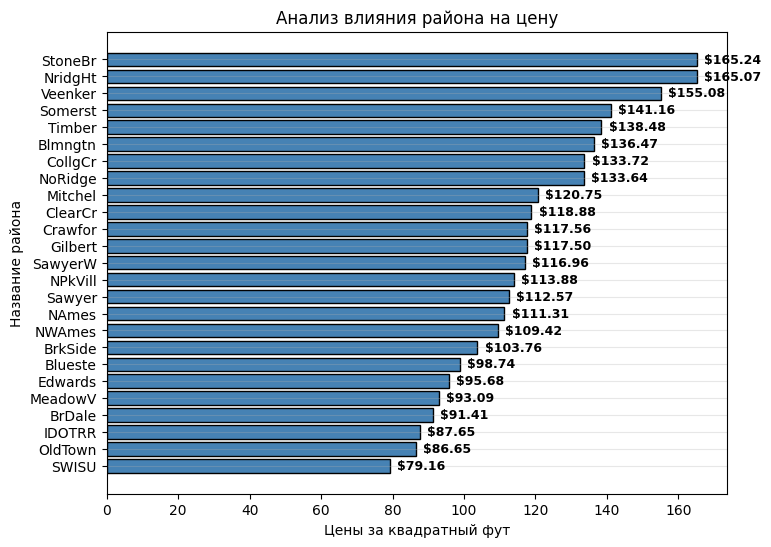

In [67]:
all_neighborhoods = set(our_df["Neighborhood"])
prices = []
for neighbor in all_neighborhoods:
    curr_neighbor = our_df[our_df["Neighborhood"] == neighbor]
    price_nighbor = round(
        float(curr_neighbor["SalePrice"].mean() / curr_neighbor["GrLivArea"].mean()), 4
    )
    prices.append(price_nighbor)
sorted_data = sorted(zip(prices,all_neighborhoods))
sorted_prices , sorted_neighbors  = zip(*sorted_data)
plt.figure(figsize=(8, 6))
plt.barh(list(sorted_neighbors), sorted_prices, color="steelblue", edgecolor="black")
plt.xlabel("Цены за квадратный фут")
plt.ylabel("Название района")
plt.title("Анализ влияния района на цену")
plt.grid(axis="y", alpha=0.3)

for i, v in enumerate(sorted_prices):
    plt.text(v + 2, i, f"${v:,.2f}", va="center", fontsize=9, fontweight="bold")


plt.show()

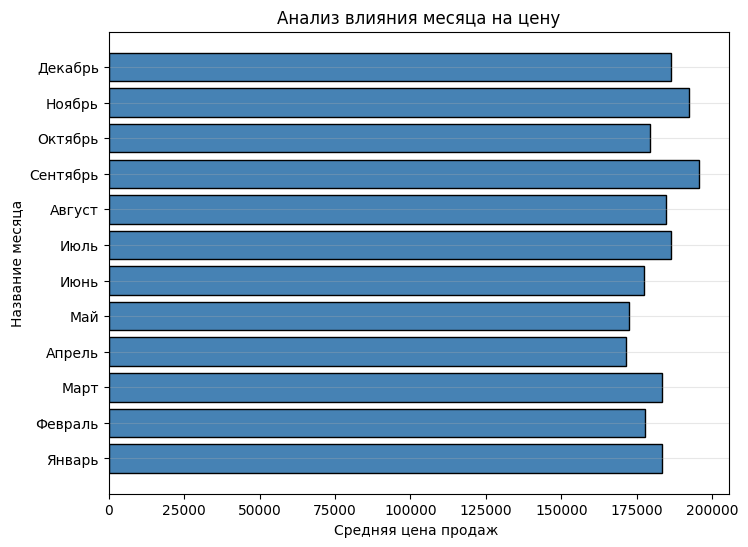

In [74]:
months = [
    "Январь", "Февраль", "Март", "Апрель", 
    "Май", "Июнь", "Июль", "Август", 
    "Сентябрь", "Октябрь", "Ноябрь", "Декабрь"
]
prices = []
for month in range(1,13):
    curr_month = our_df[our_df["MoSold"] == month]
    month_price = round(float(curr_month["SalePrice"].mean()) , 4)
    prices.append(month_price)

plt.figure(figsize=(8, 6))
plt.barh(months, prices, color="steelblue", edgecolor="black")
plt.xlabel("Средняя цена продаж ")
plt.ylabel("Название месяца")
plt.title("Анализ влияния месяца на цену")
plt.grid(axis="y", alpha=0.3)



plt.show()

ТОП-5 числовых признаков:
1. OverallQual: 0.7910
2. GrLivArea: 0.7086
3. GarageCars: 0.6404
4. GarageArea: 0.6234
5. TotalBsmtSF: 0.6136


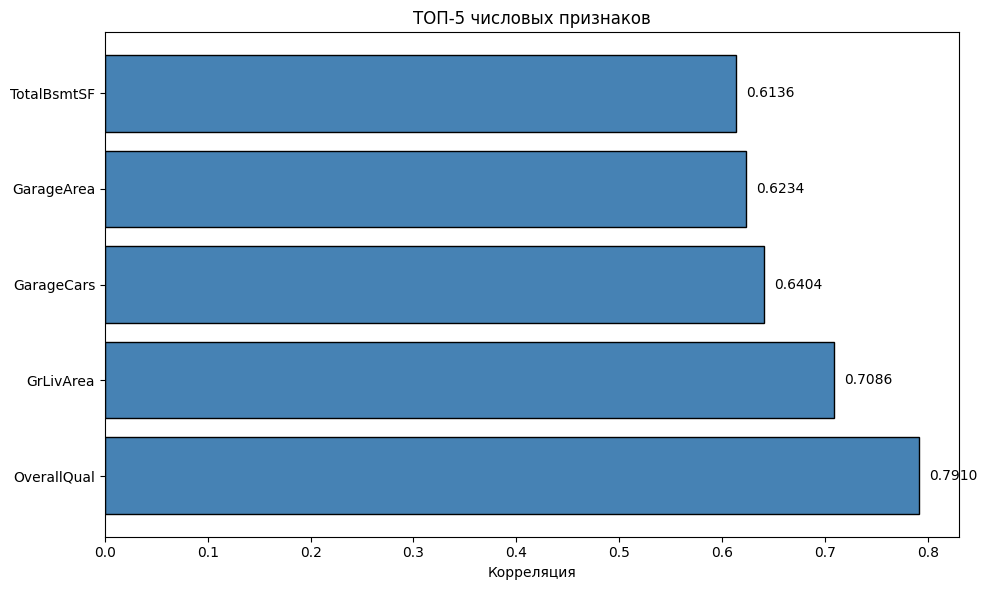

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("train.csv")

numeric_cols = df.select_dtypes(include=[np.number]).columns
correlations = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
top5_numeric = correlations[1:6]

print("ТОП-5 числовых признаков:")
for i, (feature, corr) in enumerate(top5_numeric.items(), 1):
    print(f"{i}. {feature}: {corr:.4f}")

plt.figure(figsize=(10, 6))
bars = plt.barh(range(len(top5_numeric)), top5_numeric.values, color='steelblue', edgecolor='black')
plt.yticks(range(len(top5_numeric)), top5_numeric.index)
plt.xlabel('Корреляция')
plt.title('ТОП-5 числовых признаков')
for i, (bar, val) in enumerate(zip(bars, top5_numeric.values)):
    plt.text(val + 0.01, i, f'{val:.4f}', va='center')
plt.tight_layout()
plt.show()



ТОП-5 Текстовых признаков:
1. ExterQual: +318% (лучшее: Ex, худшее: Fa)
2. Exterior1st: +269% (лучшее: ImStucc, худшее: BrkComm)
3. Neighborhood: +240% (лучшее: NoRidge, худшее: MeadowV)
4. Condition2: +236% (лучшее: PosA, худшее: RRNn)
5. BsmtCond: +234% (лучшее: Gd, худшее: Po)


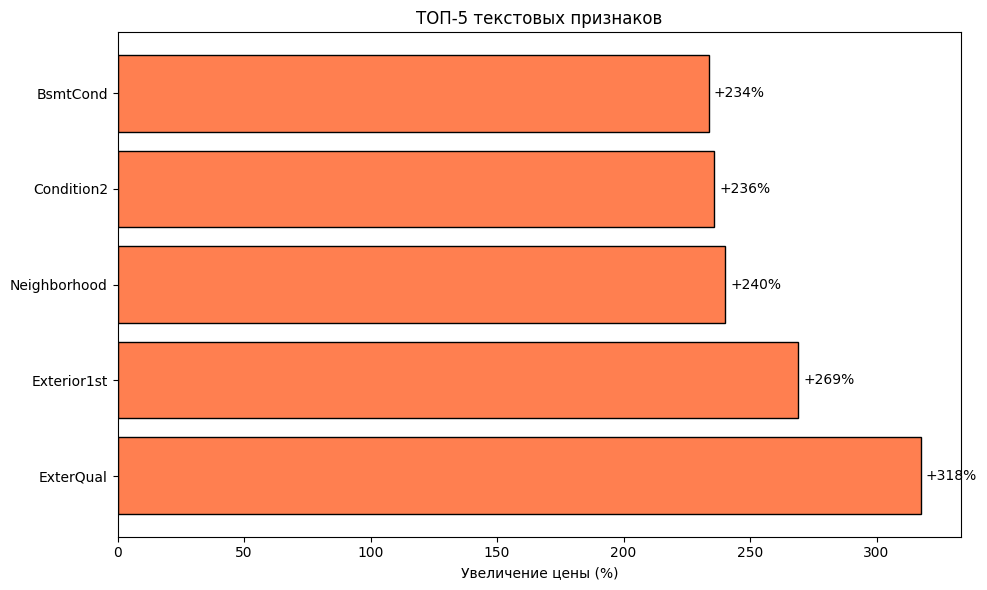

In [9]:
text_cols = df.select_dtypes(include=['str']).columns
text_results = []

for col in text_cols:
        means = df.groupby(col)['SalePrice'].mean().sort_values(ascending=False)
        if len(means) > 1:
            impact = (means.iloc[0] - means.iloc[-1]) / means.iloc[-1] * 100
            text_results.append((col, impact, means.index[0], means.index[-1]))

text_results.sort(key=lambda x: x[1], reverse=True)
top5_text = text_results[:5]

print("ТОП-5 Текстовых признаков:")
for i, (feature, impact, best, worst) in enumerate(top5_text, 1):
    print(f"{i}. {feature}: +{impact:.0f}% (лучшее: {best}, худшее: {worst})")

plt.figure(figsize=(10, 6))
impacts = [x[1] for x in top5_text]
features = [x[0] for x in top5_text]
bars = plt.barh(range(len(impacts)), impacts, color='coral', edgecolor='black')
plt.yticks(range(len(features)), features)
plt.xlabel('Увеличение цены (%)')
plt.title('ТОП-5 текстовых признаков')
for i, (bar, val) in enumerate(zip(bars, impacts)):
    plt.text(val + 2, i, f'+{val:.0f}%', va='center')
plt.tight_layout()
plt.show()
